# Machine learning test

准确率: 1.00


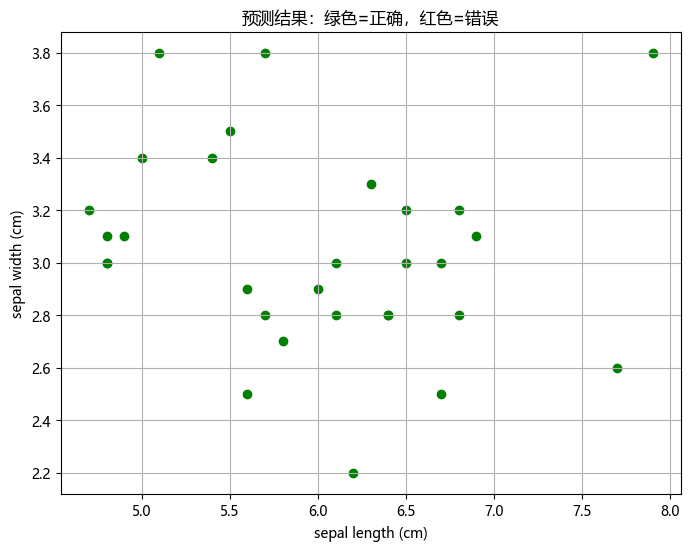

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"准确率: {acc:.2f}")
plt.rcParams['font.family'] = 'Microsoft YaHei'  # 或 'SimHei'
plt.rcParams['axes.unicode_minus'] = False  # 避免负号显示异常
plt.figure(figsize=(8,6))
for i in range(len(y_test)):
    plt.scatter(X_test[i][0], X_test[i][1], 
                c='green' if y_pred[i] == y_test[i] else 'red', 
                label='正确' if y_pred[i] == y_test[i] else '错误')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("预测结果：绿色=正确，红色=错误")
plt.grid(True)
plt.show()

# n-th least squared error fitting

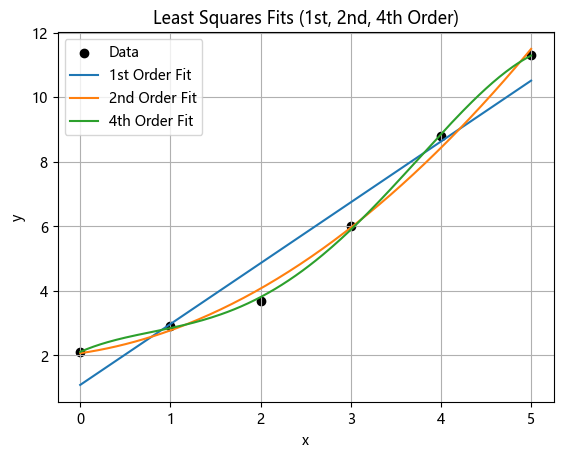

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 示例数据
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([2.1, 2.9, 3.7, 6.0, 8.8, 11.3])

# 一阶拟合（线性）
coeffs_1 = np.polyfit(x, y, 1)
poly_1 = np.poly1d(coeffs_1)
y_fit_1 = poly_1(x)

# 二阶拟合（抛物线）
coeffs_2 = np.polyfit(x, y, 2)
poly_2 = np.poly1d(coeffs_2)
y_fit_2 = poly_2(x)

# 四阶拟合
coeffs_4 = np.polyfit(x, y, 4)
poly_4 = np.poly1d(coeffs_4)
y_fit_4 = poly_4(x)

# 绘图
x_plot = np.linspace(min(x), max(x), 200)
plt.scatter(x, y, color='black', label='Data')
plt.plot(x_plot, poly_1(x_plot), label='1st Order Fit')
plt.plot(x_plot, poly_2(x_plot), label='2nd Order Fit')
plt.plot(x_plot, poly_4(x_plot), label='4th Order Fit')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares Fits (1st, 2nd, 4th Order)')
plt.grid(True)
plt.show()

# Test open nanosurf data (nid)

In [69]:
from NSFopen.read import nid_read
import numpy as np
from scipy.signal import correlate
import matplotlib.pyplot as plt

def Line_fit(image):
    image = (image - np.min(image)) 
    rows, cols = image.shape
    corrected = np.zeros_like(image)
    x = np.arange(cols)
    for i in range(rows):
        row_data = image[i, :]
        A = np.vstack([x, np.ones(cols)]).T
        slope, intercept = np.linalg.lstsq(A, row_data, rcond=None)[0]
        corrected[i, :] = row_data - (slope * x + intercept)
    return corrected

def Mean_fit(image):
    row_means = np.mean(image, axis=1, keepdims=True)
    return image - row_means

def estimate_shift(forward, backward, plot=False, unit=0.01):
    # backward_flipped = backward[::-1]
    backward_flipped = backward
    forward_centered = forward - np.mean(forward)
    backward_centered = backward_flipped - np.mean(backward_flipped)
    corr = correlate(forward_centered, backward_centered, mode='full')
    lag = np.arange(-len(forward) + 1, len(forward))
    shift = lag[np.argmax(corr)]

    if plot:
        plt.plot(lag, corr)
        plt.title(f'Cross-correlation (Estimated shift = {shift} pixels)')
        plt.xlabel('Lag (pixels)')
        plt.ylabel('Correlation')
        plt.grid(True)
        plt.show()
    
    return shift*unit


def plot_shift_histogram(Forward_image, Backward_image, Image_size, X_points):
    num_lines = Forward_image.shape[0]
    pixel_size = Image_size / X_points 
    shifts_nm = []

    for i in range(num_lines):
        forward_line = Forward_image[i]
        backward_line = Backward_image[i]
        shift_um = estimate_shift(forward_line, backward_line, plot=False, unit=pixel_size)
        shifts_nm.append(shift_um * 1000) 

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(num_lines), shifts_nm, marker='.', linestyle='-')
    plt.title("Line-wise Shift Trend (nm)")
    plt.xlabel("Line Number")
    plt.ylabel("Estimated Tip Apex (nm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


afm = nid_read(".\SCAN1900798.nid")
# afm = nid_read(".\SCAN1900938.nid")
data = afm.data
param = afm.param

Forward_image = data['Image']['Forward']['Z-Axis'] * 1e9
Backward_image = data['Image']['Backward']['Z-Axis'] * 1e9

Image_size = float(param['HeaderDump']['DataSet\DataSetInfos\Scan']['Image size'][:-3])
Image_unit = param['HeaderDump']['DataSet\DataSetInfos\Scan']['Image size'][-2:]
X_points = int(param['HeaderDump']['DataSet\DataSetInfos\Scan']['Points'])
Y_points = int(param['HeaderDump']['DataSet\DataSetInfos\Scan']['Lines'])

Forward_image = Mean_fit(Forward_image)
Backward_image = Mean_fit(Backward_image)

Forward_image = Line_fit(Forward_image)
Backward_image = Line_fit(Backward_image)

<>:63: SyntaxWarning: invalid escape sequence '\S'
<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:72: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:74: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\S'
<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:72: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:74: SyntaxWarning: invalid escape sequence '\D'
C:\Users\AIMI\AppData\Local\Temp\ipykernel_22100\3064651524.py:63: SyntaxWarning: invalid escape sequence '\S'
  afm = nid_read(".\SCAN1900798.nid")
C:\Users\AIMI\AppData\Local\Temp\ipykernel_22100\3064651524.py:71: SyntaxWarning: invalid escape sequence '\D'
  Image_size = float(param['HeaderDump']['DataSet\DataSetInfos\Scan']['Image size'][:-3])
C:\Users\AIMI\AppData\Local\Temp\ipykernel_22100\3064651524.py:72: SyntaxWarning: invalid escape sequence '\D'
  Image_unit = param['HeaderD

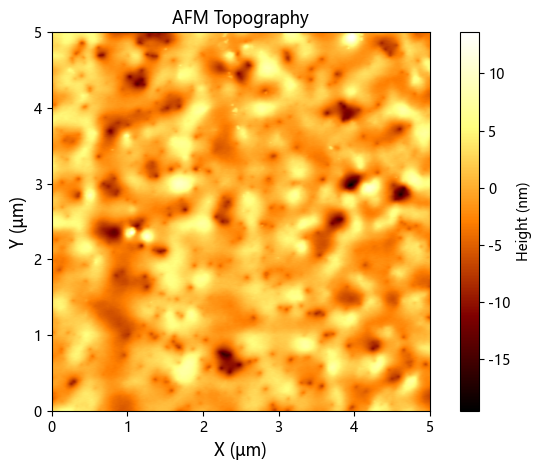

Forward_image: RMS Roughness (Sa): 2.437527 nm,  Mean Roughness (Sq): 3.149835 nm
Backward_image: RMS Roughness (Sa): 2.440991 nm,  Mean Roughness (Sq): 3.153424 nm


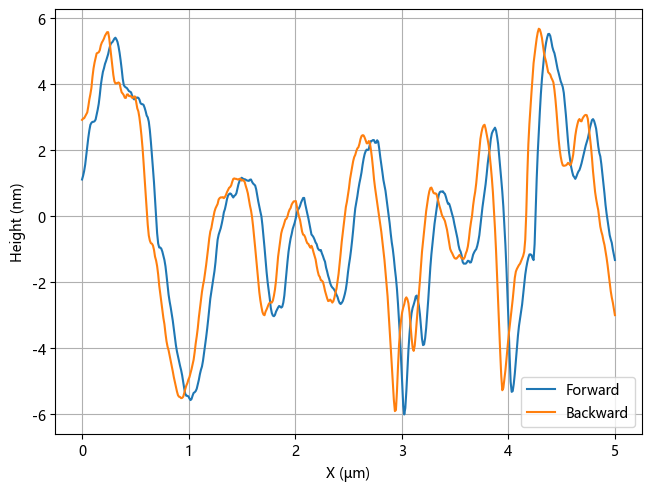

In [70]:
plt.imshow(Backward_image, extent=[0, Image_size, 0, Image_size], origin='lower',cmap='afmhot')
plt.xlabel(f'X ({Image_unit})', fontsize=12)
plt.ylabel(f'Y ({Image_unit})', fontsize=12)
cbar = plt.colorbar()
cbar.set_label('Height (nm)')
plt.title('AFM Topography', fontsize=12)
plt.tight_layout()
plt.show()

Sa = np.mean(np.abs(Forward_image - np.mean(Forward_image)))
Sq = np.sqrt(np.mean((Forward_image - np.mean(Forward_image))**2))
print('Forward_image: RMS Roughness (Sa): {:3f} nm, '.format(Sa),'Mean Roughness (Sq): {:3f} nm'.format(Sq))
Sa = np.mean(np.abs(Backward_image - np.mean(Backward_image)))
Sq = np.sqrt(np.mean((Backward_image - np.mean(Backward_image))**2))
print('Backward_image: RMS Roughness (Sa): {:3f} nm, '.format(Sa),'Mean Roughness (Sq): {:3f} nm'.format(Sq))

x = np.linspace(0, Image_size, X_points)
y = np.linspace(0, Image_size, Y_points)
# plt.plot(y,Forward_image[:,2])
# plt.plot(y,Backward_image[:,2])
plt.plot(x, Forward_image[2], label='Forward')
plt.plot(x, Backward_image[2], label='Backward')
plt.legend()  
plt.grid(True)                      
plt.tight_layout()

plt.xlabel(f'X ({Image_unit})')
plt.ylabel('Height (nm)')
plt.show()

The tip apex is around 87.89 nm @ Line 2


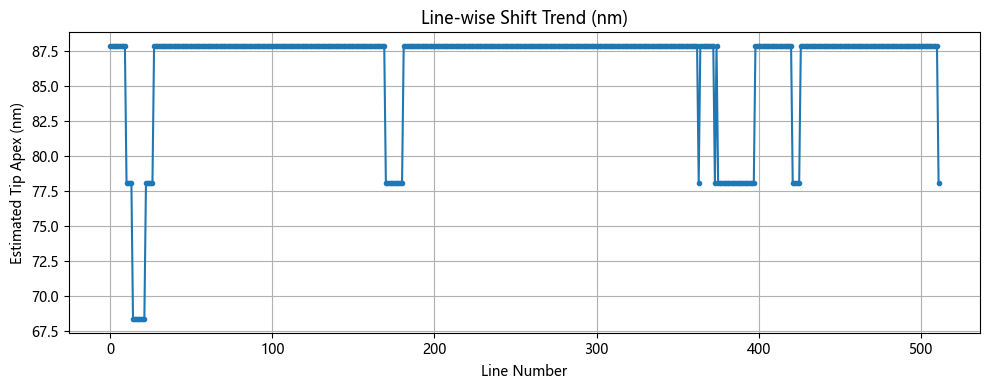

In [72]:
forwardline = Forward_image[2]
backwardline = Backward_image[2]
Estimated_tip_apex = estimate_shift(forwardline, backwardline, plot=False, unit=Image_size/X_points)
print("The tip apex is around {:.2f}".format(Estimated_tip_apex*1000), "nm @ Line 2")
plot_shift_histogram(Forward_image, Backward_image, Image_size, X_points)